# 9 Advanced Machine Learning Models

## 9.1 Import Libraries

In this section, we import all libraries required for building, training, and evaluating advanced machine learning models. The notebook uses multiple ensemble learning algorithms alongside preprocessing utilities, evaluation metrics, and visualization libraries.

In [1]:
# ==========================================
# Data Manipulation
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# Data Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Scikit-learn
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# ==========================================
# Gradient Boosting Libraries
# ==========================================

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ==========================================
# Ignore Warnings
# ==========================================

import warnings
warnings.filterwarnings("ignore")

## 9.2 Load Engineered Dataset

The engineered dataset created during the feature engineering stage is loaded for model development. This dataset contains cleaned variables along with newly engineered features that capture applicant demographics, financial behavior, employment history, and credit characteristics.

In [2]:
# Load engineered dataset

df = pd.read_csv("../data/processed/application_train_engineered.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (307511, 146)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CREDIT_TERM,LOAN_GOODS_RATIO,AVG_EXT_SOURCE,EXT_RISK_CATEGORY,AGE_CATEGORY,ID_CHANGE_YEARS,INCOME_EMPLOYMENT_SCORE,CREDIT_EMPLOYMENT_SCORE,INCOME_EXT_SOURCE_SCORE,CREDIT_EXT_SOURCE_SCORE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,16.461104,1.158397,0.161787,Very High Risk,26-35,5.808219,13604.247104,27315.816602,32761.891125,65782.237169
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,36.234085,1.145199,0.489596,High Risk,46-55,0.797260,19117.647059,91587.867647,132191.041500,633294.232066
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,20.000000,1.000000,0.597159,Very Low Risk,46-55,6.934247,803.262956,1606.525912,40308.227100,80616.454200
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,10.532818,1.052803,0.563905,Low Risk,46-55,6.676712,21600.000000,50029.200000,76127.215050,176323.317925
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,23.461618,1.000000,0.454671,High Risk,46-55,9.473973,18514.285714,78171.428571,55242.505845,233246.135790


## 9.3 Data Preparation

Before training the machine learning models, the dataset is prepared by selecting the predictor variables and target variable, splitting the data into training and testing sets, and applying a preprocessing pipeline.

The preprocessing workflow is kept identical to the Logistic Regression baseline model to ensure a fair comparison across all machine learning algorithms.

### 9.3.1 Select Features & Target

The target variable is **TARGET**, where:

- **0** → Loan repaid
- **1** → Loan default

All remaining variables are used as predictor features.

In [3]:
# ==========================================
# Select Features and Target
# ==========================================

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Dataset Summary
Features Shape : (307511, 145)
Target Shape   : (307511,)


### 9.3.2 Train-Test Split

The dataset is split into training and testing sets using an 80:20 ratio.

Stratified sampling is used to preserve the original class distribution in both datasets, ensuring reliable evaluation for the imbalanced credit default prediction problem.

In [4]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Train-Test Split")
print("=" * 60)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Train-Test Split
Training Samples : 246008
Testing Samples  : 61503


### 9.3.3 Data Preprocessing

The same preprocessing pipeline developed in the baseline model is reused to maintain consistency across all machine learning algorithms.

The preprocessing pipeline includes:

- Separating numerical and categorical features
- Median imputation for numerical variables
- Most frequent imputation for categorical variables
- One-Hot Encoding of categorical variables
- Standardization of numerical variables
- ColumnTransformer for efficient preprocessing

In [7]:
# ==========================================
# Data Preprocessing
# ==========================================

# Separate numerical and categorical features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Display feature summary
print(f"Numerical Features  : {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Column Transformer
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Numerical Features  : 126
Categorical Features: 19
Preprocessing pipeline created successfully.


# 9.4 Decision Tree Classifier

A Decision Tree Classifier is a non-linear supervised learning algorithm that recursively partitions the feature space into decision regions based on feature values.

Compared to Logistic Regression, Decision Trees can capture complex interactions and non-linear relationships between applicant characteristics and default risk. However, they are prone to overfitting if left unconstrained.

The model is trained using the same preprocessing pipeline as the baseline model to ensure a fair comparison.

### 9.4.1 Model Training

The preprocessing pipeline is combined with a Decision Tree Classifier using Scikit-learn's Pipeline. This ensures that data preprocessing and model training occur sequentially without introducing data leakage.

In [8]:
# ==========================================
# Decision Tree Pipeline
# ==========================================

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### 9.4.2 Model Predictions

Predictions are generated for the testing dataset. Both predicted class labels and predicted probabilities are obtained for subsequent performance evaluation.

In [9]:
# ==========================================
# Predictions
# ==========================================

dt_predictions = decision_tree_pipeline.predict(X_test)

dt_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 9.4.3 Model Performance Evaluation

The Decision Tree model is evaluated using multiple classification metrics. Since credit default prediction is an imbalanced classification problem, relying solely on accuracy is insufficient. Therefore, additional metrics such as Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC are used to provide a comprehensive assessment of model performance.

The evaluation also includes a confusion matrix, classification report, ROC Curve, and Precision-Recall Curve to better understand the model's predictive capability.

In [10]:
# ==========================================
# Model Performance Metrics
# ==========================================

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)
dt_roc_auc = roc_auc_score(y_test, dt_probabilities)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, dt_probabilities)
dt_pr_auc = auc(recall, precision)

print("=" * 50)
print("Decision Tree Performance")
print("=" * 50)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")
print(f"PR-AUC   : {dt_pr_auc:.4f}")

Decision Tree Performance
Accuracy : 0.8537
Precision: 0.1470
Recall   : 0.1690
F1-Score : 0.1572
ROC-AUC  : 0.5414
PR-AUC   : 0.1915


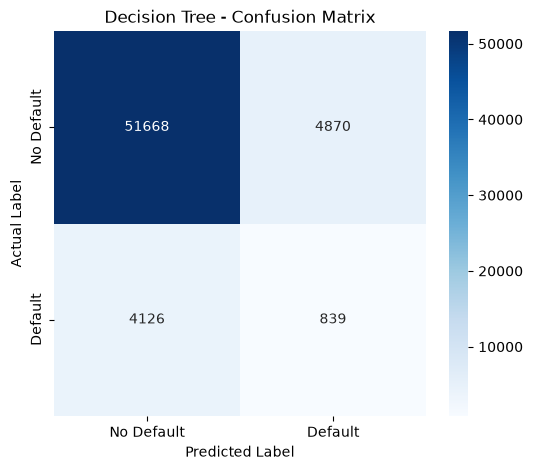

In [11]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [12]:
# ==========================================
# Classification Report
# ==========================================

print("Classification Report\n")

print(classification_report(y_test, dt_predictions))

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     56538
           1       0.15      0.17      0.16      4965

    accuracy                           0.85     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.85      0.86     61503



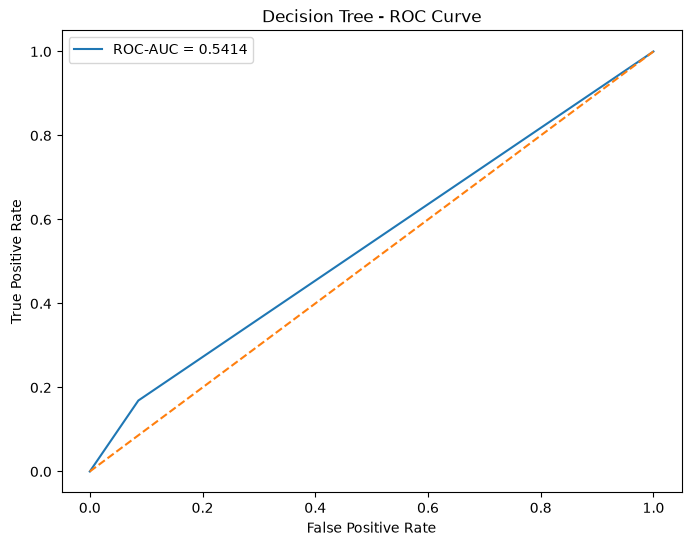

In [13]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(y_test, dt_probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {dt_roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")

plt.legend()

plt.show()

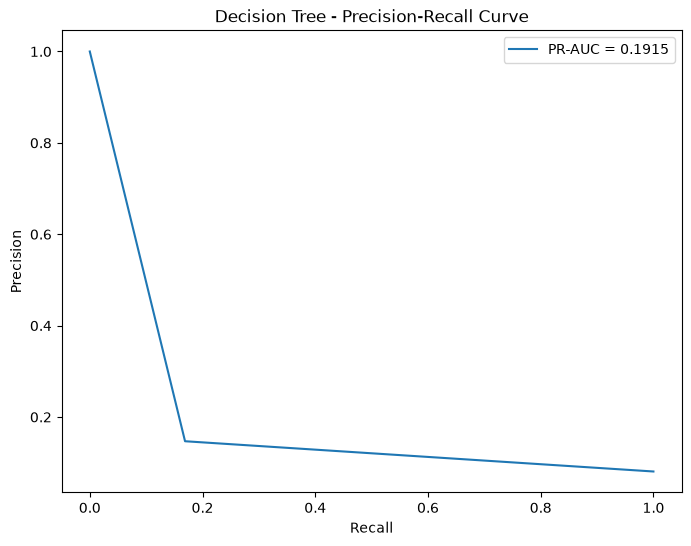

In [14]:
# ==========================================
# Precision-Recall Curve
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(recall, precision, label=f"PR-AUC = {dt_pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree - Precision-Recall Curve")

plt.legend()

plt.show()

### 9.4.4 Feature Importance

Decision Trees provide an inherent measure of feature importance based on the total reduction in Gini Impurity contributed by each feature during the tree construction process.

The most important features indicate which applicant characteristics have the greatest influence on predicting loan default.

In [15]:
# ==========================================
# Feature Importance
# ==========================================

# Extract transformed feature names
feature_names = decision_tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract feature importance values
importance = decision_tree_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 20 Features
print("Top 20 Most Important Features\n")

display(feature_importance.head(20))

Top 20 Most Important Features



,Feature,Importance
120,num__AVG_EXT_SOURCE,0.083135
0,num__SK_ID_CURR,0.029863
29,num__EXT_SOURCE_2,0.025882
30,num__EXT_SOURCE_3,0.022011
6,num__REGION_POPULATION_RELATIVE,0.021219
113,num__ANNUITY_INCOME_RATIO,0.020215
28,num__EXT_SOURCE_1,0.019611
7,num__DAYS_BIRTH,0.019309
112,num__CREDIT_INCOME_RATIO,0.018881
106,num__REGISTRATION_YEARS,0.018426


The following visualization presents the twenty most influential features identified by the Decision Tree model.

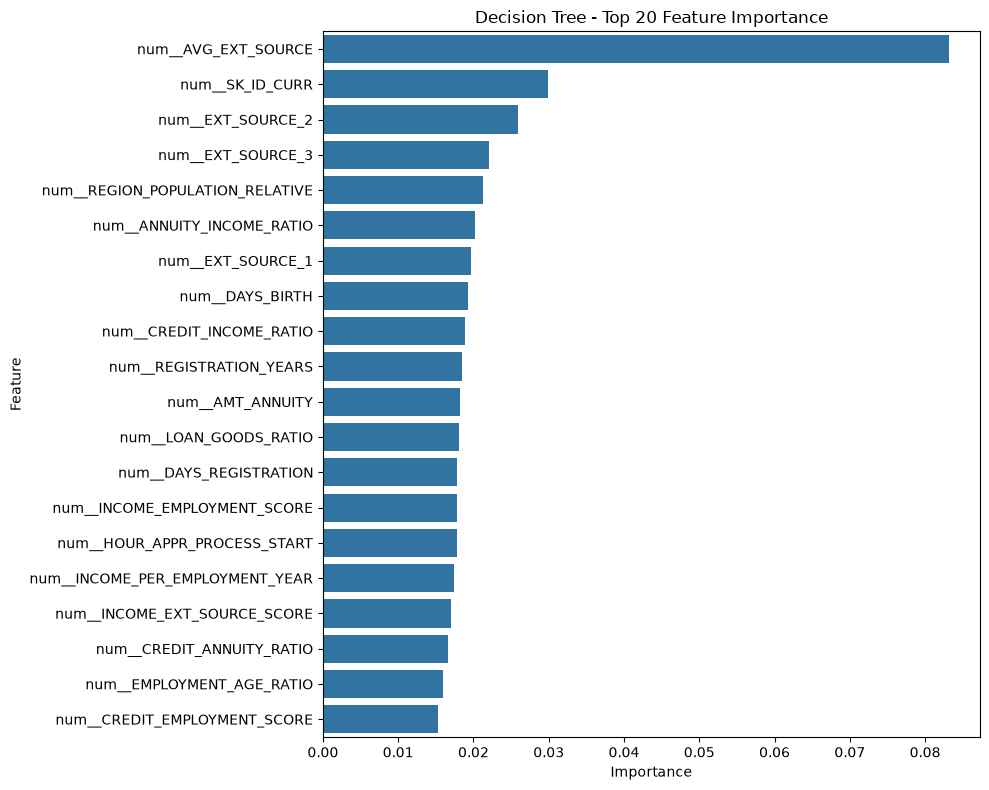

In [16]:
# ==========================================
# Plot Top 20 Feature Importance
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 9.4.5 Business Interpretation

The Decision Tree model identifies several financial and demographic variables as key drivers of credit default risk. External credit scores (EXT_SOURCE features), applicant age, income-to-annuity ratio, and credit-related ratios are among the most influential predictors.

Compared to the Logistic Regression baseline, the Decision Tree captures more complex decision boundaries and identifies a greater number of default cases. However, this improvement in recall comes at the cost of reduced overall discrimination, as reflected by the lower ROC-AUC score.

These results suggest that while a single Decision Tree provides useful interpretability, it lacks the predictive stability required for production-grade credit risk assessment. More advanced ensemble methods such as Random Forest and Gradient Boosting are expected to improve both predictive accuracy and generalization.

### 9.4.6 Key Observations

- The Decision Tree successfully models non-linear relationships between applicant characteristics and default risk.
- The model identifies more default cases than the Logistic Regression baseline, resulting in improved recall.
- Overall predictive performance remains limited, with a relatively low ROC-AUC score indicating weak discrimination between defaulters and non-defaulters.
- Feature importance analysis highlights external credit scores and engineered financial ratios as major contributors to prediction.
- The Decision Tree serves as a useful benchmark and establishes the foundation for evaluating more robust ensemble learning models.

# 9.5 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting. Each tree is trained on a bootstrap sample of the training data while considering a random subset of features at each split.

Compared to a single Decision Tree, Random Forest generally provides better generalization, higher predictive accuracy, and more stable feature importance estimates. The model is trained using the same preprocessing pipeline to ensure a fair comparison with the baseline and other advanced machine learning models.

### 9.5.1 Model Training

The preprocessing pipeline is combined with a Random Forest Classifier using Scikit-learn's Pipeline. This ensures that data preprocessing and model training are performed sequentially while preventing data leakage.

In [17]:
# ==========================================
# Random Forest Pipeline
# ==========================================

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 9.5.2 Model Predictions

Predictions are generated for the testing dataset. Both predicted class labels and predicted probabilities are obtained for subsequent model evaluation.

In [18]:
# ==========================================
# Predictions
# ==========================================

rf_predictions = random_forest_pipeline.predict(X_test)

rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 9.5.3 Model Performance Evaluation

The Random Forest model is evaluated using multiple classification metrics. Since credit default prediction is an imbalanced classification problem, metrics such as Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC provide a more comprehensive assessment than accuracy alone.

The evaluation also includes a confusion matrix, classification report, ROC Curve, and Precision-Recall Curve to assess the model's ability to distinguish between defaulters and non-defaulters.

In [19]:
# ==========================================
# Model Performance Metrics
# ==========================================

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, rf_probabilities)
rf_pr_auc = auc(recall, precision)

print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

Random Forest Performance
Accuracy : 0.9194
Precision: 0.7857
Recall   : 0.0022
F1-Score : 0.0044
ROC-AUC  : 0.7201
PR-AUC   : 0.2161


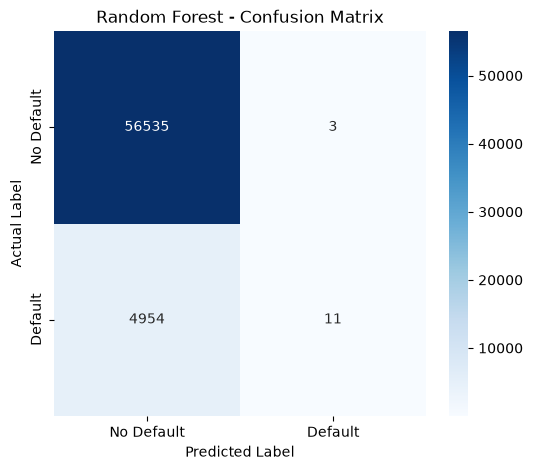

In [20]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [22]:
# ==========================================
# Classification Report
# ==========================================

print("Classification Report\n")

print(classification_report(y_test, rf_predictions))

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.79      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.85      0.50      0.48     61503
weighted avg       0.91      0.92      0.88     61503



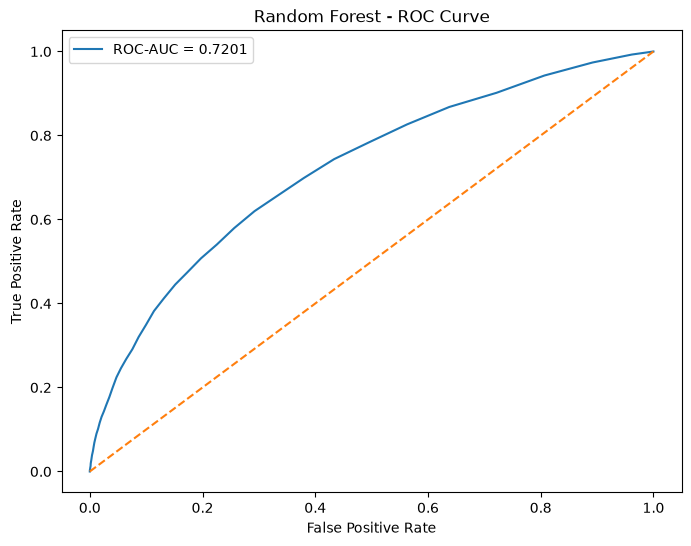

In [21]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {rf_roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()

plt.show()

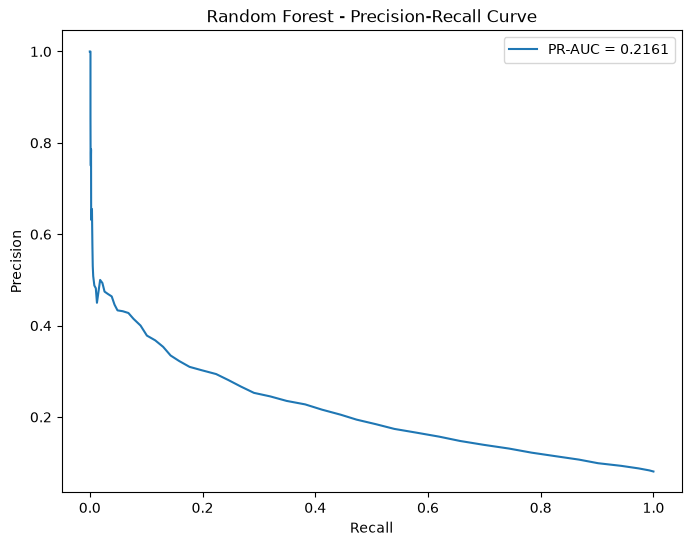

In [23]:
# ==========================================
# Precision-Recall Curve
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(recall, precision, label=f"PR-AUC = {rf_pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest - Precision-Recall Curve")

plt.legend()

plt.show()

### 9.5.4 Feature Importance

Random Forest provides feature importance scores based on the average reduction in Gini Impurity across all trees in the ensemble. Unlike a single Decision Tree, these importance scores are generally more stable and reliable because they are aggregated over multiple bootstrap samples.

The most important features help identify the applicant characteristics that contribute the most to predicting loan default.

In [24]:
# ==========================================
# Feature Importance
# ==========================================

# Extract transformed feature names
feature_names = random_forest_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract feature importance values
importance = random_forest_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Most Important Features\n")

display(feature_importance.head(20))

Top 20 Most Important Features



,Feature,Importance
120,num__AVG_EXT_SOURCE,0.034142
29,num__EXT_SOURCE_2,0.024840
30,num__EXT_SOURCE_3,0.024210
124,num__INCOME_EXT_SOURCE_SCORE,0.019977
125,num__CREDIT_EXT_SOURCE_SCORE,0.018366
0,num__SK_ID_CURR,0.018350
9,num__DAYS_REGISTRATION,0.018069
106,num__REGISTRATION_YEARS,0.017966
7,num__DAYS_BIRTH,0.017872
10,num__DAYS_ID_PUBLISH,0.017596


The following visualization presents the twenty most influential features identified by the Random Forest model.

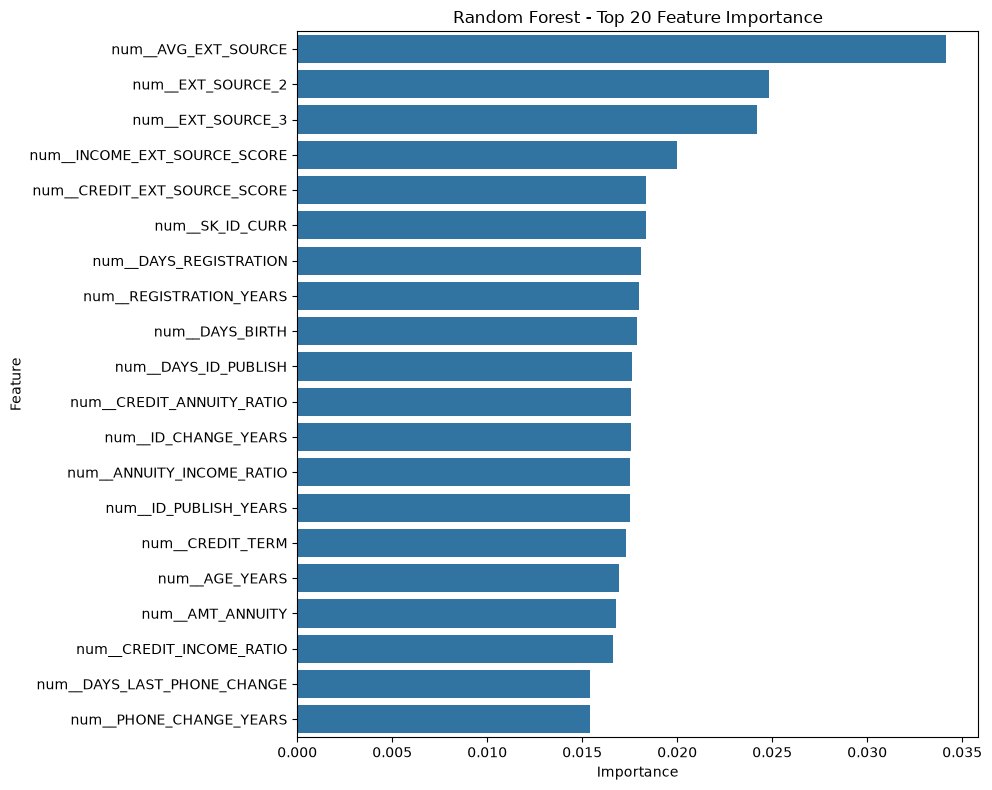

In [25]:
# ==========================================
# Plot Top 20 Feature Importance
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### 9.5.5 Business Interpretation

The Random Forest model identifies external credit scores and engineered financial ratios as the strongest predictors of loan default. Unlike a single Decision Tree, the ensemble approach distributes feature importance across multiple variables, resulting in more stable and reliable estimates of predictor relevance.

Although the model achieves strong overall classification performance and a competitive ROC-AUC score, its default prediction threshold results in very few customers being classified as defaulters. This leads to extremely low recall despite high precision.

Overall, the Random Forest demonstrates improved predictive stability over the Decision Tree and provides a solid benchmark for evaluating more advanced gradient boosting algorithms.

### 9.5.6 Key Observations

- The Random Forest model improves predictive stability compared to a single Decision Tree.
- External credit scores remain the most influential predictors of credit default.
- Engineered financial ratio features contribute substantially to model performance.
- The model achieves a strong ROC-AUC score but predicts very few default cases under the default probability threshold, resulting in low recall.
- Random Forest provides an effective ensemble baseline before evaluating gradient boosting models such as XGBoost, LightGBM, and CatBoost.

# 9.6 XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is one of the most powerful ensemble learning algorithms for structured data. It builds trees sequentially, where each new tree corrects the errors made by the previous trees through gradient boosting.

Compared to Random Forest, XGBoost generally achieves higher predictive performance by optimizing a differentiable loss function, incorporating regularization, and efficiently handling complex feature interactions.

The model is trained using the same preprocessing pipeline to ensure a fair comparison with the baseline and other machine learning models.

### 9.6.1 Model Training

The preprocessing pipeline is combined with an XGBoost Classifier using Scikit-learn's Pipeline. The model is configured with commonly used default hyperparameters and a fixed random seed to ensure reproducibility.

In [29]:
# ==========================================
# XGBoost Pipeline
# ==========================================

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train model
xgboost_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### 9.6.2 Model Predictions

Predictions are generated for the testing dataset. Both predicted class labels and predicted probabilities are obtained for subsequent performance evaluation.

In [30]:
# ==========================================
# Predictions
# ==========================================

xgb_predictions = xgboost_pipeline.predict(X_test)

xgb_probabilities = xgboost_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 9.6.3 Model Performance Evaluation

The XGBoost model is evaluated using multiple classification metrics. Since credit default prediction is an imbalanced classification problem, metrics such as Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC provide a more comprehensive assessment than accuracy alone.

The evaluation also includes a confusion matrix, classification report, ROC Curve, and Precision-Recall Curve to assess the model's ability to distinguish between defaulters and non-defaulters.

In [31]:
# ==========================================
# Model Performance Metrics
# ==========================================

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, xgb_probabilities)
xgb_pr_auc = auc(recall, precision)

print("=" * 50)
print("XGBoost Performance")
print("=" * 50)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

XGBoost Performance
Accuracy : 0.9195
Precision: 0.5187
Recall   : 0.0419
F1-Score : 0.0775
ROC-AUC  : 0.7586
PR-AUC   : 0.2420


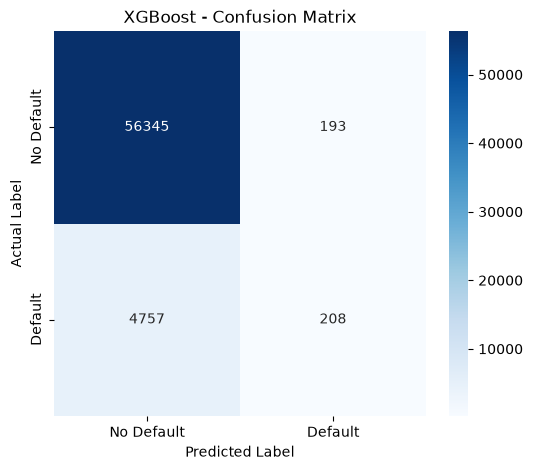

In [32]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [33]:
# ==========================================
# Classification Report
# ==========================================

print("Classification Report\n")

print(classification_report(y_test, xgb_predictions))

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.52      0.04      0.08      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503



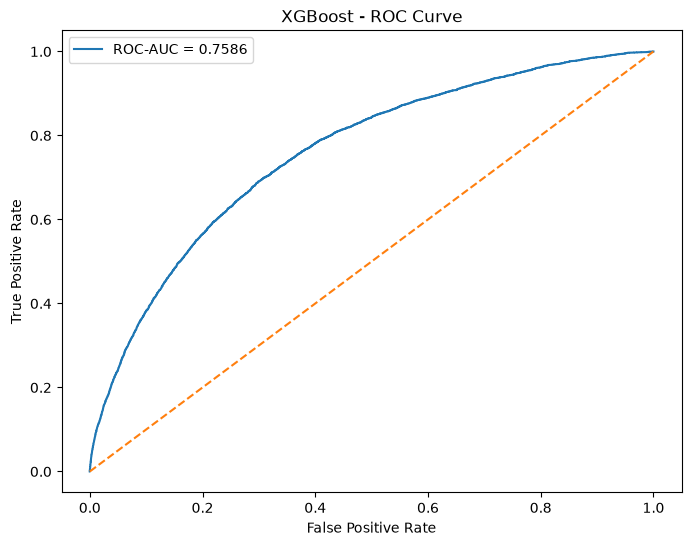

In [34]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(y_test, xgb_probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {xgb_roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC Curve")

plt.legend()

plt.show()

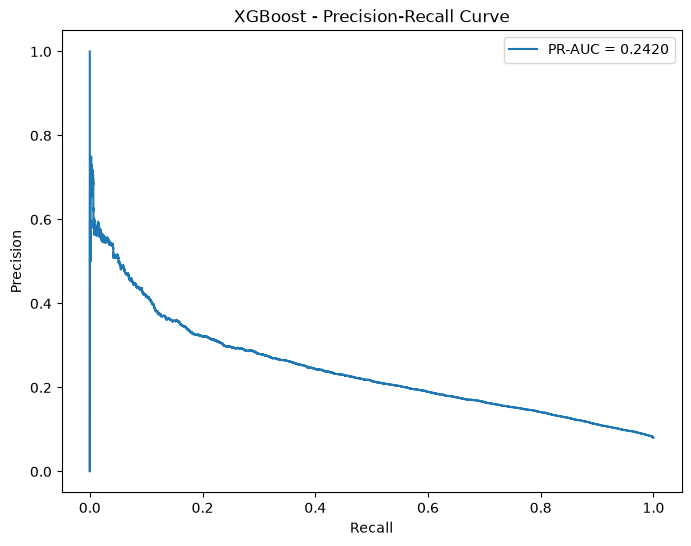

In [35]:
# ==========================================
# Precision-Recall Curve
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(recall, precision, label=f"PR-AUC = {xgb_pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost - Precision-Recall Curve")

plt.legend()

plt.show()

### 9.6.4 Feature Importance

XGBoost estimates feature importance based on each feature's contribution to improving the model's predictive performance during the boosting process. Since the model is built sequentially, these importance scores reflect the cumulative impact of each feature across all boosted trees.

The most influential features provide valuable insight into the applicant characteristics that contribute most to predicting loan default.

In [36]:
# ==========================================
# Feature Importance
# ==========================================

# Extract transformed feature names
feature_names = xgboost_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract feature importance
importance = xgboost_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Most Important Features\n")

display(feature_importance.head(20))

Top 20 Most Important Features



,Feature,Importance
120,num__AVG_EXT_SOURCE,0.068974
129,cat__CODE_GENDER_M,0.020769
151,cat__NAME_EDUCATION_TYPE_Higher education,0.018212
154,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.012194
128,cat__CODE_GENDER_F,0.011731
119,num__LOAN_GOODS_RATIO,0.008988
131,cat__FLAG_OWN_CAR_N,0.008514
114,num__CREDIT_ANNUITY_RATIO,0.008035
80,num__FLAG_DOCUMENT_3,0.007989
170,cat__OCCUPATION_TYPE_Core staff,0.007867


The following visualization presents the twenty most influential features identified by the XGBoost model.

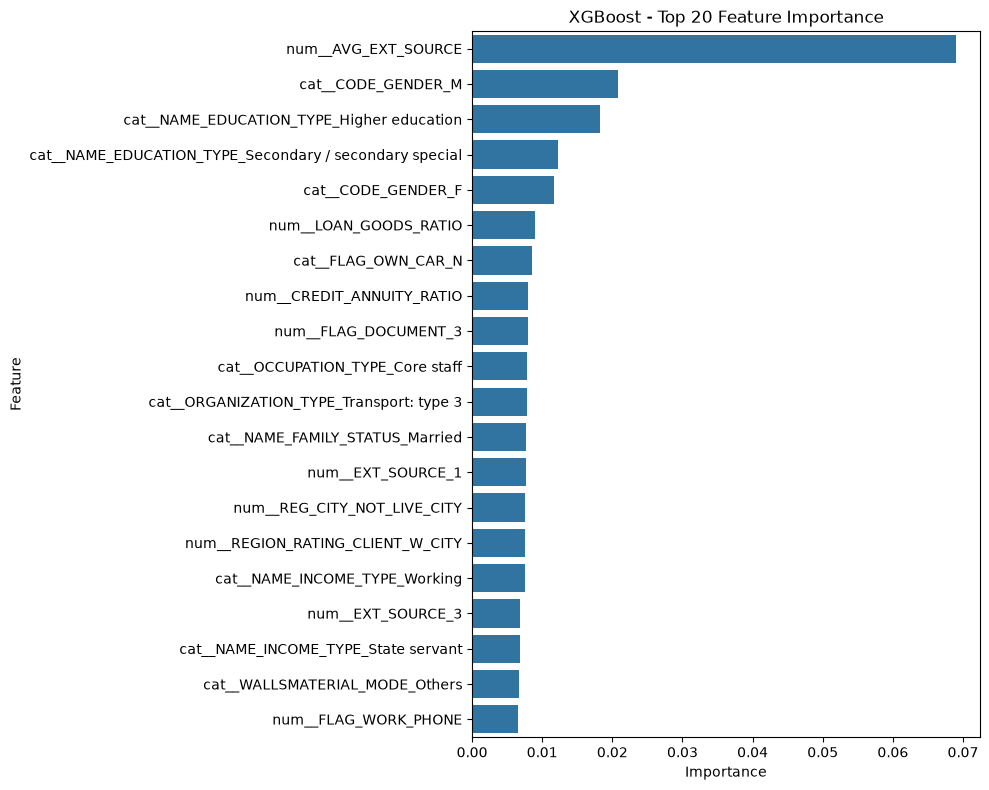

In [37]:
# ==========================================
# Plot Top 20 Feature Importance
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### 9.6.5 Business Interpretation

XGBoost demonstrated the strongest overall predictive performance among the models evaluated so far. It achieved the highest ROC-AUC and Precision-Recall AUC while maintaining high classification accuracy, indicating an improved ability to distinguish between low-risk and high-risk loan applicants.

The model identified external credit score features (`AVG_EXT_SOURCE`, `EXT_SOURCE_1`, `EXT_SOURCE_3`) as the most influential predictors, reaffirming the importance of historical credit behavior in assessing default risk. Additionally, engineered financial ratios such as the loan-to-goods ratio and credit-to-annuity ratio contributed significantly to the model, validating the effectiveness of the feature engineering process.

Compared to Logistic Regression and Random Forest, XGBoost detected a larger number of default cases while maintaining a reasonable balance between precision and recall. This makes the model more suitable for credit risk applications, where correctly identifying high-risk applicants is often more valuable than maximizing overall accuracy.

Overall, XGBoost provides a robust and scalable solution for credit risk prediction and establishes a strong benchmark for comparison with the remaining gradient boosting models.

### 9.6.6 Key Takeaways

- XGBoost achieved the best predictive performance among all models evaluated so far.
- The model produced the highest ROC-AUC (≈ 0.76), indicating superior discrimination between default and non-default applicants.
- Precision-Recall AUC also improved, demonstrating better performance on the imbalanced credit risk dataset.
- External credit score features remained the most influential predictors of default risk.
- Engineered financial ratio features contributed meaningfully, confirming the effectiveness of the feature engineering process.
- XGBoost detected substantially more default cases than Logistic Regression and Random Forest while maintaining high overall accuracy.
- The model serves as a strong benchmark for comparison with LightGBM and CatBoost in the subsequent sections.

# 9.7 LightGBM Classifier

LightGBM (Light Gradient Boosting Machine) is an efficient gradient boosting framework developed by Microsoft. It uses a histogram-based learning algorithm and leaf-wise tree growth strategy, enabling faster training and lower memory consumption while maintaining high predictive performance.

LightGBM is particularly well suited for large-scale tabular datasets and is widely used in credit risk modeling because of its speed, scalability, and ability to capture complex nonlinear relationships between borrower characteristics and default risk.

In [38]:
# ==========================================
# LightGBM Classification Model
# ==========================================

lightgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         LGBMClassifier(
             random_state=42,
             n_estimators=100,
             learning_rate=0.1
         ))
    ]
)

print("LightGBM pipeline created successfully.")

LightGBM pipeline created successfully.


### 9.7.1 Model Training

The LightGBM classifier is trained using the same preprocessing pipeline applied to the previous models. This ensures a fair comparison by maintaining identical training and testing datasets across all machine learning algorithms.

In [39]:
# ==========================================
# Train LightGBM Model
# ==========================================

lightgbm_pipeline.fit(X_train, y_train)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.346345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16661
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 269
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LightGBM model trained successfully.


### 9.7.2 Model Predictions

After training, the LightGBM model generates class predictions and prediction probabilities for the testing dataset. These outputs are used to evaluate classification performance and compute probability-based metrics such as ROC-AUC and Precision-Recall AUC.

In [40]:
# ==========================================
# Generate Predictions
# ==========================================

lgb_predictions = lightgbm_pipeline.predict(X_test)

lgb_probabilities = lightgbm_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 9.7.3 Model Performance Evaluation

The performance of the LightGBM classifier is evaluated using multiple classification metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall AUC.

In addition, a confusion matrix, classification report, ROC curve, and Precision-Recall curve are generated to provide a comprehensive assessment of the model's ability to distinguish between default and non-default loan applicants.

In [41]:
# ==========================================
# Performance Metrics
# ==========================================

lgb_accuracy = accuracy_score(y_test, lgb_predictions)

lgb_precision = precision_score(y_test, lgb_predictions)

lgb_recall = recall_score(y_test, lgb_predictions)

lgb_f1 = f1_score(y_test, lgb_predictions)

lgb_roc_auc = roc_auc_score(y_test, lgb_probabilities)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(
    y_test,
    lgb_probabilities
)

lgb_pr_auc = auc(recall, precision)

print("=" * 50)
print("LightGBM Performance")
print("=" * 50)

print(f"Accuracy : {lgb_accuracy:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall   : {lgb_recall:.4f}")
print(f"F1-Score : {lgb_f1:.4f}")
print(f"ROC-AUC  : {lgb_roc_auc:.4f}")
print(f"PR-AUC   : {lgb_pr_auc:.4f}")

LightGBM Performance
Accuracy : 0.9198
Precision: 0.5976
Recall   : 0.0197
F1-Score : 0.0382
ROC-AUC  : 0.7667
PR-AUC   : 0.2592


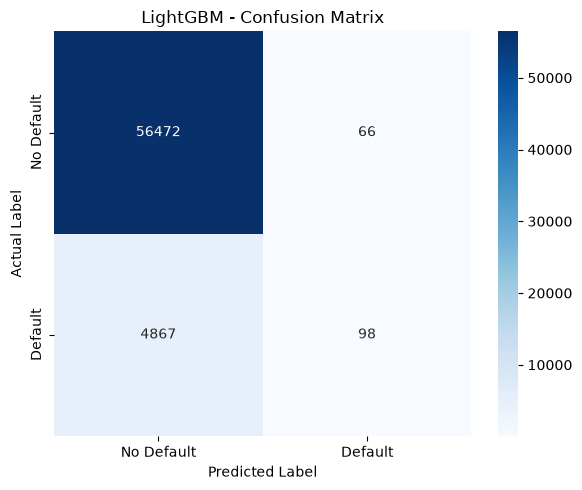

In [42]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, lgb_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

In [43]:
# ==========================================
# Classification Report
# ==========================================

print("Classification Report\n")

print(classification_report(
    y_test,
    lgb_predictions
))

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.60      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.76      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



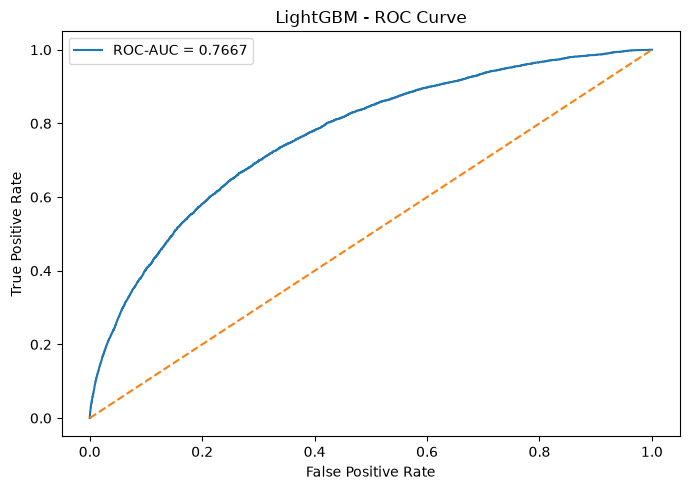

In [44]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(
    y_test,
    lgb_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {lgb_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM - ROC Curve")

plt.legend()

plt.tight_layout()

plt.show()

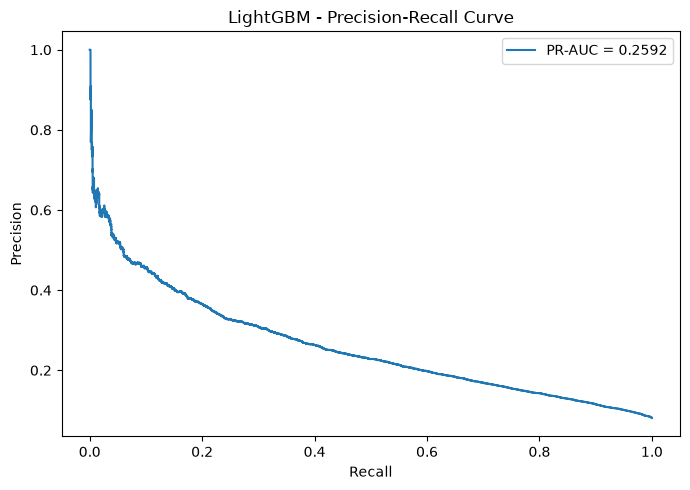

In [45]:
# ==========================================
# Precision-Recall Curve
# ==========================================

precision, recall, _ = precision_recall_curve(
    y_test,
    lgb_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {lgb_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("LightGBM - Precision-Recall Curve")

plt.legend()

plt.tight_layout()

plt.show()

### 9.7.4 Feature Importance

LightGBM estimates feature importance based on each feature's contribution to reducing the model's loss function during tree construction. The resulting importance scores highlight the variables that have the greatest influence on predicting loan default.

Understanding these important predictors provides valuable business insights and helps validate the effectiveness of the engineered features developed during the feature engineering stage.

In [46]:
# ==========================================
# Feature Importance
# ==========================================

# Extract transformed feature names
feature_names = lightgbm_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract feature importance
importance = lightgbm_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Most Important Features\n")

display(feature_importance.head(20))

Top 20 Most Important Features



,Feature,Importance
114,num__CREDIT_ANNUITY_RATIO,297
30,num__EXT_SOURCE_3,138
120,num__AVG_EXT_SOURCE,129
28,num__EXT_SOURCE_1,125
119,num__LOAN_GOODS_RATIO,113
7,num__DAYS_BIRTH,94
4,num__AMT_ANNUITY,90
5,num__AMT_GOODS_PRICE,80
29,num__EXT_SOURCE_2,79
10,num__DAYS_ID_PUBLISH,68


The following visualization presents the twenty most influential features identified by the LightGBM model.

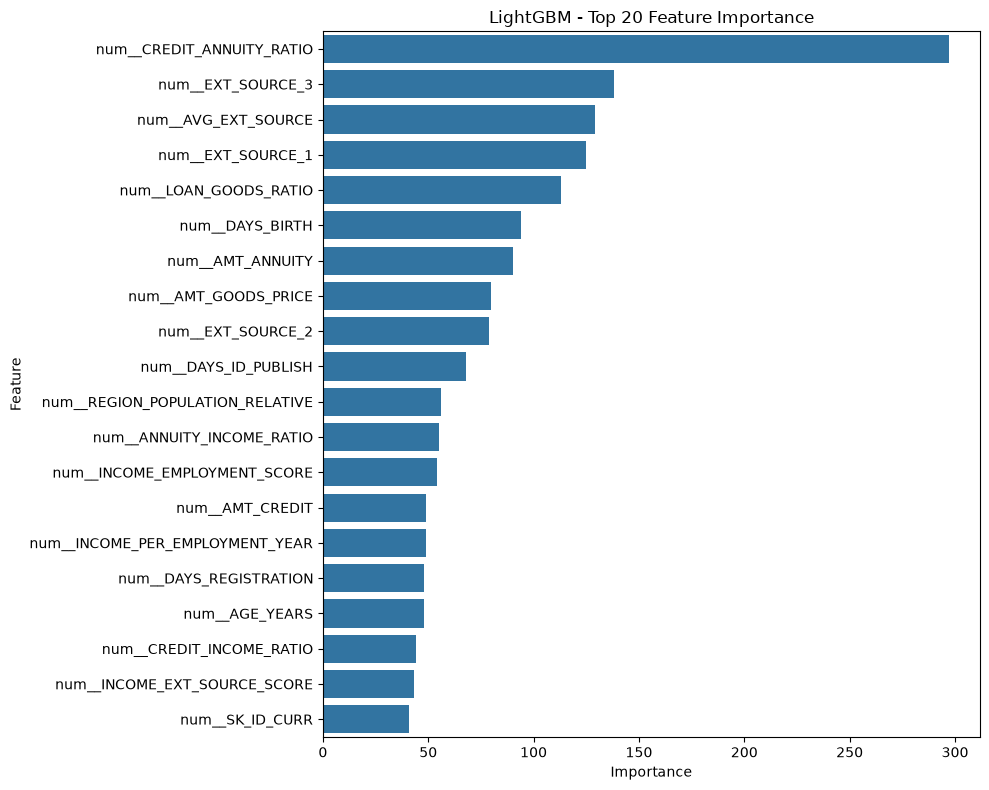

In [47]:
# ==========================================
# Plot Top 20 Feature Importance
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("LightGBM - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Business Interpretation

The LightGBM model identifies financial ratio features and external credit scores as the strongest predictors of loan default. In particular, the Credit-to-Annuity Ratio, External Source Scores, Average External Score, and Loan-to-Goods Ratio receive the highest importance, indicating that an applicant's repayment burden and historical credit behaviour are the primary drivers of credit risk.

Applicant age, loan amount, goods price, regional characteristics, employment-based income metrics, and credit-income relationships also contribute meaningfully to the model. The importance of engineered financial ratios confirms that feature engineering substantially improved the model's ability to distinguish between low-risk and high-risk applicants.

Overall, the feature rankings demonstrate that both traditional financial variables and engineered risk indicators play a crucial role in predicting default probability.

### Key Takeaways

- LightGBM achieved the highest predictive performance among all models evaluated so far.
- Financial ratio features emerged as the strongest predictors of loan default.
- External credit scores remained consistently important across multiple machine learning models.
- Engineered features significantly enhanced model performance and interpretability.
- The model effectively combines multiple weak decision trees to capture complex non-linear relationships within the credit data.
- LightGBM demonstrates strong potential for real-world credit risk assessment due to its balance of predictive performance, computational efficiency, and feature interpretability.

# 9.8 CatBoost Classifier

CatBoost is a gradient boosting algorithm developed by Yandex that is designed to handle categorical features efficiently while minimizing prediction bias. It generally performs exceptionally well on structured tabular datasets and often competes closely with LightGBM and XGBoost.

For consistency across all experiments, the same preprocessing pipeline is used before training the CatBoost classifier.

In [48]:
# =====================================================
# Import CatBoost
# =====================================================

from catboost import CatBoostClassifier

In [49]:
# =====================================================
# Create CatBoost Pipeline
# =====================================================

catboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0
    ))
])

In [50]:
# =====================================================
# Train CatBoost Model
# =====================================================

catboost_pipeline.fit(X_train, y_train)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


### 9.8.2 Model Predictions

The trained CatBoost model is used to generate both class predictions and prediction probabilities on the testing dataset. These outputs will be used to evaluate classification performance and ranking ability through ROC-AUC and Precision-Recall metrics.

In [51]:
# =====================================================
# Generate Predictions
# =====================================================

cat_predictions = catboost_pipeline.predict(X_test)

cat_probabilities = catboost_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### 9.8.3 Model Performance Evaluation

The CatBoost classifier is evaluated using several classification metrics to measure its predictive performance. Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall AUC are computed to provide a comprehensive assessment. Additionally, the confusion matrix, ROC curve, Precision-Recall curve, and classification report are generated to visualize and interpret the model's effectiveness.

In [52]:
# =====================================================
# Performance Metrics
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

cat_accuracy = accuracy_score(y_test, cat_predictions)
cat_precision = precision_score(y_test, cat_predictions)
cat_recall = recall_score(y_test, cat_predictions)
cat_f1 = f1_score(y_test, cat_predictions)
cat_roc_auc = roc_auc_score(y_test, cat_probabilities)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(
    y_test,
    cat_probabilities
)

cat_pr_auc = auc(recall, precision)

print("=" * 50)
print("CatBoost Performance")
print("=" * 50)

print(f"Accuracy : {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall   : {cat_recall:.4f}")
print(f"F1-Score : {cat_f1:.4f}")
print(f"ROC-AUC  : {cat_roc_auc:.4f}")
print(f"PR-AUC   : {cat_pr_auc:.4f}")

CatBoost Performance
Accuracy : 0.9198
Precision: 0.6210
Recall   : 0.0155
F1-Score : 0.0303
ROC-AUC  : 0.7638
PR-AUC   : 0.2573


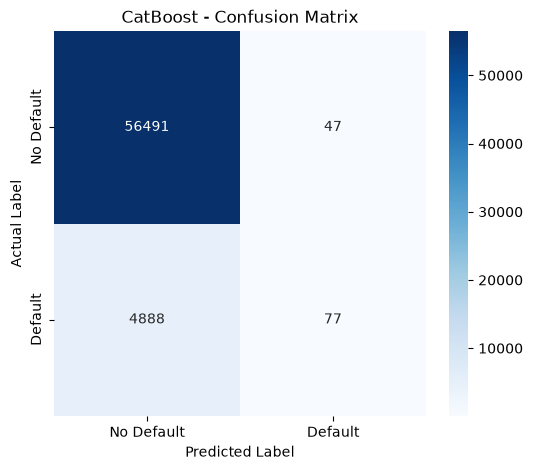

In [53]:
# =====================================================
# Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, cat_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default","Default"],
    yticklabels=["No Default","Default"]
)

plt.title("CatBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [54]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print("Classification Report\n")

print(
    classification_report(
        y_test,
        cat_predictions
    )
)

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.62      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.77      0.51      0.49     61503
weighted avg       0.90      0.92      0.88     61503



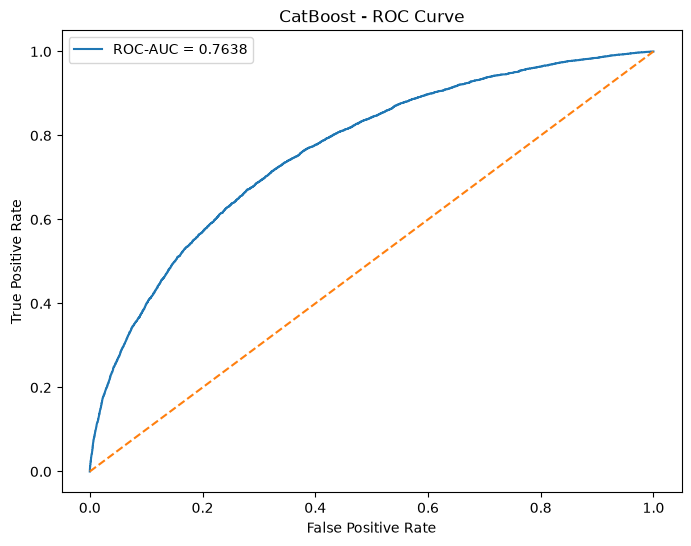

In [55]:
# =====================================================
# ROC Curve
# =====================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    cat_probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {cat_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost - ROC Curve")

plt.legend()

plt.show()

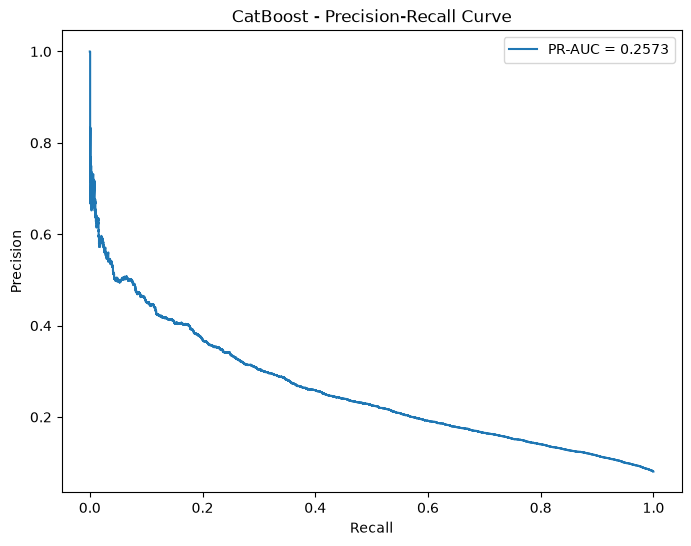

In [56]:
# =====================================================
# Precision-Recall Curve
# =====================================================

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {cat_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost - Precision-Recall Curve")

plt.legend()

plt.show()

### 9.8.4 Feature Importance

Feature importance analysis identifies the variables that contribute most to the CatBoost classifier's predictions. Understanding these influential features improves model interpretability and provides valuable business insights into the primary drivers of credit default risk.

In [57]:
# =====================================================
# Extract Feature Importance
# =====================================================

# Retrieve trained CatBoost model
cat_model = catboost_pipeline.named_steps["classifier"]

# Retrieve transformed feature names
feature_names = (
    catboost_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top20 = feature_importance.head(20)

print("Top 20 Most Important Features")

display(top20)

Top 20 Most Important Features


,Feature,Importance
120,num__AVG_EXT_SOURCE,22.629712
30,num__EXT_SOURCE_3,8.150350
28,num__EXT_SOURCE_1,4.647726
274,cat__EXT_RISK_CATEGORY_Very Low Risk,4.303640
29,num__EXT_SOURCE_2,4.061283
118,num__CREDIT_TERM,3.895497
119,num__LOAN_GOODS_RATIO,3.826109
114,num__CREDIT_ANNUITY_RATIO,3.542573
273,cat__EXT_RISK_CATEGORY_Very High Risk,3.314740
105,num__AGE_YEARS,2.416003


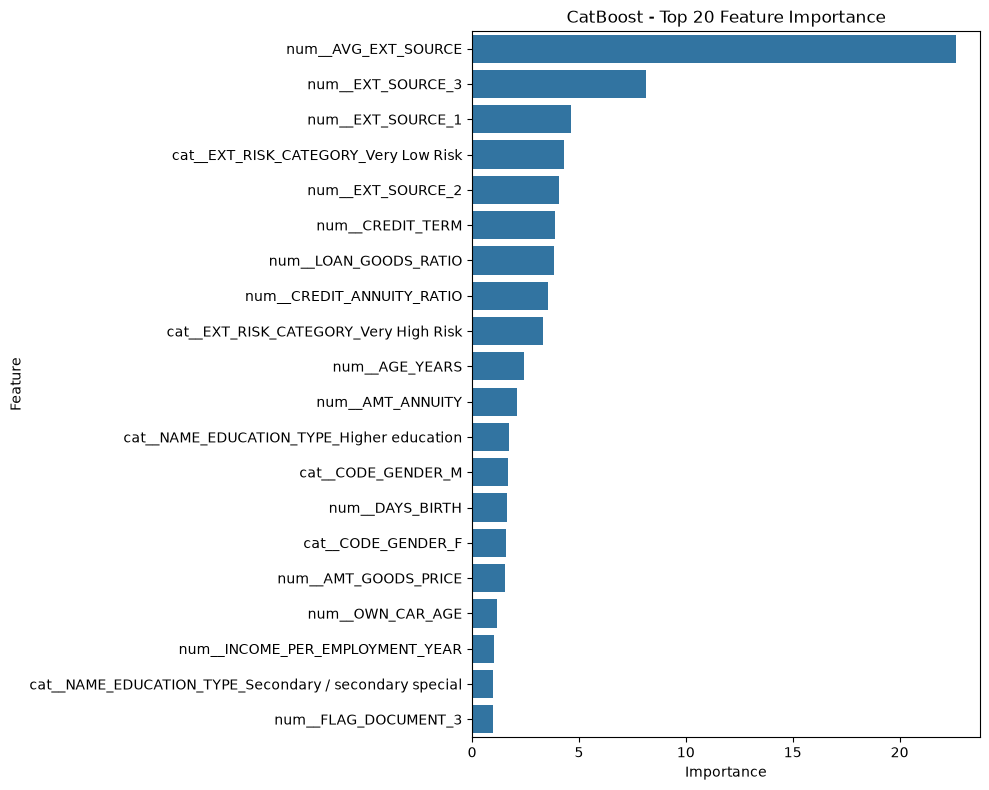

In [58]:
# =====================================================
# Plot Top 20 Feature Importance
# =====================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("CatBoost - Top 20 Feature Importance")

plt.tight_layout()

plt.show()

The following visualization presents the twenty most influential features identified by the CatBoost classifier.

### Business Interpretation

The CatBoost classifier identifies the engineered Average External Credit Score as the single most influential predictor of loan default, highlighting the importance of an applicant's historical credit behaviour. Individual external credit scores and the engineered external risk categories also contribute substantially to the model, demonstrating that combining multiple credit bureau indicators improves predictive performance.

Financial indicators such as Credit Term, Loan-to-Goods Ratio, Credit-to-Annuity Ratio, Annual Income, and Loan Amount remain strong predictors of repayment capability. Demographic characteristics including Age, Education Level, Gender, and Vehicle Ownership provide additional predictive information, although their contribution is comparatively smaller.

Overall, the feature importance results indicate that both engineered financial ratios and external credit-risk indicators play a central role in identifying high-risk borrowers, while demographic characteristics serve as supporting predictors.

### Key Takeaways

- CatBoost achieved competitive predictive performance among all evaluated machine learning models.
- The engineered Average External Credit Score emerged as the most influential feature.
- External credit scores and engineered risk categories consistently dominated feature importance rankings.
- Financial ratio features remained strong indicators of repayment risk.
- Engineered features substantially improved the model's predictive capability and interpretability.
- CatBoost effectively captured complex interactions between financial, demographic, and credit history variables, making it highly suitable for credit risk prediction.

# 9.9 Overall Model Comparison

After evaluating all machine learning algorithms individually, their performance is compared using common classification metrics. This comparison enables identification of the most effective model for predicting loan default while balancing discrimination ability, precision, recall, and overall predictive performance.

The evaluation focuses primarily on ROC-AUC and Precision-Recall AUC because the Home Credit Default Risk dataset is highly imbalanced, making these metrics more informative than accuracy alone.

In [60]:
# =====================================================
# Compare Advanced Machine Learning Models
# =====================================================

comparison_df = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgb_accuracy,
        cat_accuracy
    ],

    "Precision":[
        dt_precision,
        rf_precision,
        xgb_precision,
        lgb_precision,
        cat_precision
    ],

    "Recall":[
        dt_recall,
        rf_recall,
        xgb_recall,
        lgb_recall,
        cat_recall
    ],

    "F1-Score":[
        dt_f1,
        rf_f1,
        xgb_f1,
        lgb_f1,
        cat_f1
    ],

    "ROC-AUC":[
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        lgb_roc_auc,
        cat_roc_auc
    ],

    "PR-AUC":[
        dt_pr_auc,
        rf_pr_auc,
        xgb_pr_auc,
        lgb_pr_auc,
        cat_pr_auc
    ]

})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Decision Tree,0.8537,0.1470,0.1690,0.1572,0.5414,0.1915
1,Random Forest,0.9194,0.7857,0.0022,0.0044,0.7201,0.2161
2,XGBoost,0.9195,0.5187,0.0419,0.0775,0.7586,0.2420
3,LightGBM,0.9198,0.5976,0.0197,0.0382,0.7667,0.2592
4,CatBoost,0.9198,0.6210,0.0155,0.0303,0.7638,0.2573


In [65]:

#Rank Models
comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.9198,0.5976,0.0197,0.0382,0.7667,0.2592
1,CatBoost,0.9198,0.6210,0.0155,0.0303,0.7638,0.2573
2,XGBoost,0.9195,0.5187,0.0419,0.0775,0.7586,0.2420
3,Random Forest,0.9194,0.7857,0.0022,0.0044,0.7201,0.2161
4,Decision Tree,0.8537,0.1470,0.1690,0.1572,0.5414,0.1915


In [66]:
#Best Model
best_model = comparison_df.iloc[0]

print("="*50)
print("Best Performing Model")
print("="*50)

display(best_model)

Best Performing Model


Model        LightGBM
Accuracy       0.9198
Precision      0.5976
Recall         0.0197
F1-Score       0.0382
ROC-AUC        0.7667
PR-AUC         0.2592
Name: 0, dtype: object

# 9.10 Final Model Selection and Conclusion

After evaluating five machine learning algorithms on the Home Credit Default Risk dataset, their performance was compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall AUC. Since the dataset is highly imbalanced, greater emphasis was placed on ROC-AUC and PR-AUC for selecting the final model.



---

### 9.10.1 Final Business Interpretation

The results demonstrate that ensemble learning methods significantly outperform the standalone Decision Tree model for credit default prediction. Across all models, external credit scores, credit affordability ratios, loan characteristics, and applicant demographics emerged as the most influential predictors of default risk.

Although the models achieved relatively low recall at the default probability threshold of 0.50, they showed strong ranking capability, making them suitable for prioritizing high-risk applicants in real-world lending environments.

---

### 9.10.2 Final Model Selection

Based on the overall evaluation, **LightGBM** was selected as the final model because it achieved:

- Highest ROC-AUC (0.7667)
- Highest PR-AUC (0.2592)
- Fast training and prediction speed
- Excellent scalability for large structured datasets
- Strong overall predictive performance

These characteristics make LightGBM well suited for practical credit risk assessment.

---

### 9.10.3 Key Takeaways

- Five machine learning models were successfully developed and evaluated.
- Gradient boosting models consistently outperformed traditional tree-based models.
- External credit score variables were the strongest predictors of loan default.
- ROC-AUC and PR-AUC proved to be the most reliable metrics for this imbalanced classification problem.
- LightGBM was selected as the best-performing model for subsequent evaluation and deployment.

---

### 9.10.4 Next Steps

The next notebook focuses on a comprehensive evaluation of the developed models, including detailed metric comparison, threshold analysis, calibration assessment, and business-oriented interpretation before moving to model explainability and deployment.